<a href="https://colab.research.google.com/github/saramaknojia94-ux/no-show-prediction/blob/main/noshow_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Patient No-Show Prediction

Started looking into this because no-shows are a real operational
problem in clinical environments. The question I wanted to answer:
is there a pattern in who doesn't show up, and can we catch it
before the appointment?

Dataset is 110k appointments from Brazilian clinics. Fields include
patient demographics, appointment details, SMS reminders, and
whether the patient showed up.

Starting with just exploration, want to understand the data before
jumping to modeling.

In [1]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

path = kagglehub.dataset_download("joniarroba/noshowappointments")
print("downloaded to:", path)

100%|██████████| 2.40M/2.40M [00:00<00:00, 110MB/s]

Extracting files...
downloaded to: /root/.cache/kagglehub/datasets/joniarroba/noshowappointments/versions/5


In [2]:
import os
# find the actual file name in the downloaded folder
files = os.listdir(path)
print("files in download:", files)
# load it
df = pd.read_csv(path + '/' + files[0])
print("shape:", df.shape)
print("\ncolumns:", df.columns.tolist())
df.head()

files in download: ['KaggleV2-May-2016.csv']
shape: (110527, 14)

columns: ['PatientId', 'AppointmentID', 'Gender', 'ScheduledDay', 'AppointmentDay', 'Age', 'Neighbourhood', 'Scholarship', 'Hipertension', 'Diabetes', 'Alcoholism', 'Handcap', 'SMS_received', 'No-show']


,PatientId,AppointmentID,Gender,ScheduledDay,AppointmentDay,Age,Neighbourhood,Scholarship,Hipertension,Diabetes,Alcoholism,Handcap,SMS_received,No-show
0,2.987250e+13,5642903,F,2016-04-29T18:38:08Z,2016-04-29T00:00:00Z,62,JARDIM DA PENHA,0,1,0,0,0,0,No
1,5.589978e+14,5642503,M,2016-04-29T16:08:27Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,0,0,0,0,0,No
2,4.262962e+12,5642549,F,2016-04-29T16:19:04Z,2016-04-29T00:00:00Z,62,MATA DA PRAIA,0,0,0,0,0,0,No
3,8.679512e+11,5642828,F,2016-04-29T17:29:31Z,2016-04-29T00:00:00Z,8,PONTAL DE CAMBURI,0,0,0,0,0,0,No
4,8.841186e+12,5642494,F,2016-04-29T16:07:23Z,2016-04-29T00:00:00Z,56,JARDIM DA PENHA,0,1,1,0,0,0,No


First look at the data. 14 columns — target is "No-show" (Yes/No).
Interesting fields: SMS_received, Hipertension, Scholarship, wait time
between ScheduledDay and AppointmentDay. Those feel like they could
matter a lot. Age too.

Going to check the no-show rate first, then start digging into patterns.

In [3]:
# how many people actually no-showed
noshow_counts = df['No-show'].value_counts()
noshow_rate = df['No-show'].value_counts(normalize=True) * 100

print("no-show counts:")
print(noshow_counts)
print("\nno-show rate:")
print(noshow_rate.round(1))

# quick look at age range and any obvious issues
print("\nage range:", df['Age'].min(), "to", df['Age'].max())
print("any negative ages?", (df['Age'] < 0).sum())

no-show counts:
No-show
No     88208
Yes    22319
Name: count, dtype: int64

no-show rate:
No-show
No     79.8
Yes    20.2
Name: proportion, dtype: float64

age range: -1 to 115
any negative ages? 1


20.2% no-show rate overall. So roughly 1 in 5 patients doesn't show up.

Two things caught my eye:
- Someone has age -1, which is clearly a data entry error. Only 1 row
  so will just drop it.
- Age goes up to 115 which is unusual but not impossible.

The 80/20 split means the data is imbalanced — most patients DO show up.
This will matter when we build the model later. A model that just
predicts "show" every time would be 80% accurate but completely useless.

In [4]:
# drop the one row with negative age - obvious data entry error
df = df[df['Age'] >= 0]

# convert scheduled and appointment days to datetime
df['ScheduledDay'] = pd.to_datetime(df['ScheduledDay'])
df['AppointmentDay'] = pd.to_datetime(df['AppointmentDay'])

# calculate wait time in days - this feels like it could be important
df['wait_days'] = (df['AppointmentDay'] - df['ScheduledDay']).dt.days

# some wait times are negative (appointment before scheduling?) - check
print("negative wait times:", (df['wait_days'] < 0).sum())
print("wait time range:", df['wait_days'].min(), "to", df['wait_days'].max())
print("\nwait time summary:")
print(df['wait_days'].describe().round(1))

negative wait times: 38567
wait time range: -7 to 178

wait time summary:
count    110526.0
mean          9.2
std          15.3
min          -7.0
25%          -1.0
50%           3.0
75%          14.0
max         178.0
Name: wait_days, dtype: float64


Interesting problem — 38,567 rows have negative wait times, meaning
the appointment was scheduled AFTER it supposedly happened. That's
clearly a data issue, likely same-day appointments being logged
after the fact.

Decided to floor wait_days at 0 rather than drop all those rows —
losing 35% of the data would hurt the model more than the noise.
Same-day appointments are still valid appointments.

Average wait time is 9 days, max is 178 days. That's a long time
to wait — curious if longer waits really do mean more no-shows.

In [5]:
# floor wait days at 0 - same day appointments treated as 0 wait
df['wait_days'] = df['wait_days'].clip(lower=0)

# extract day of week from appointment - mondays might be different
df['appt_weekday'] = df['AppointmentDay'].dt.day_name()

# create binary target column
df['no_show'] = (df['No-show'] == 'Yes').astype(int)

# quick look at no-show rate by day of week
weekday_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday']
noshow_by_day = df.groupby('appt_weekday')['no_show'].mean() * 100
noshow_by_day = noshow_by_day.reindex(weekday_order)

print("no-show rate by day of week:")
print(noshow_by_day.round(1))

no-show rate by day of week:
appt_weekday
Monday       20.6
Tuesday      20.1
Wednesday    19.7
Thursday     19.4
Friday       21.2
Saturday     23.1
Name: no_show, dtype: float64


Day of week does show some variation but not as dramatic as expected.
Saturday has the highest no-show rate at 23.1% — makes sense,
people schedule weekend appointments and then have other plans.
Friday is second highest at 21.2%.

Not a massive signal on its own but worth keeping as a feature
in the model. Going to look at SMS reminders next — that feels
like it should matter a lot.

In [6]:
# does getting an SMS reminder actually help?
sms_noshow = df.groupby('SMS_received')['no_show'].mean() * 100
print("no-show rate by SMS received:")
print(sms_noshow.round(1))
print("\n0 = no SMS, 1 = received SMS")

# no-show rate by age group
df['age_group'] = pd.cut(df['Age'],
                          bins=[0, 18, 30, 45, 60, 75, 115],
                          labels=['0-18','19-30','31-45','46-60','61-75','75+'])

age_noshow = df.groupby('age_group', observed=True)['no_show'].mean() * 100
print("\nno-show rate by age group:")
print(age_noshow.round(1))

# wait time vs no-show
df['wait_bucket'] = pd.cut(df['wait_days'],
                            bins=[-1, 0, 7, 30, 60, 180],
                            labels=['same-day','1-7 days',
                                    '8-30 days','31-60 days','60+ days'])

wait_noshow = df.groupby('wait_bucket', observed=True)['no_show'].mean() * 100
print("\nno-show rate by wait time:")
print(wait_noshow.round(1))

no-show rate by SMS received:
SMS_received
0    16.7
1    27.6
Name: no_show, dtype: float64

0 = no SMS, 1 = received SMS

no-show rate by age group:
age_group
0-18     22.5
19-30    24.7
31-45    21.4
46-60    17.8
61-75    14.9
75+      16.1
Name: no_show, dtype: float64

no-show rate by wait time:
wait_bucket
same-day       6.6
1-7 days      25.0
8-30 days     32.0
31-60 days    34.1
60+ days      28.8
Name: no_show, dtype: float64


Three really clear patterns here:

SMS reminders: counterintuitive finding — patients who received SMS
reminders had a HIGHER no-show rate (27.6%) than those who didn't
(16.7%). My guess is that SMS reminders are sent more often for
longer-wait appointments, and longer waits drive no-shows. The SMS
itself probably isn't causing no-shows — it's a proxy for wait time.

Age: younger patients (19-30) no-show most at 24.7%. Older patients
(61-75) are most reliable at 14.9%. This makes clinical sense —
older patients tend to take their health more seriously.

Wait time: this is the strongest signal I've seen so far. Same-day
appointments have only 6.6% no-show rate. That jumps to 34% for
31-60 day waits. The longer someone has to wait, the more likely
life gets in the way.

These three variables — wait_days, age, SMS_received — are going
to be important features in the model.

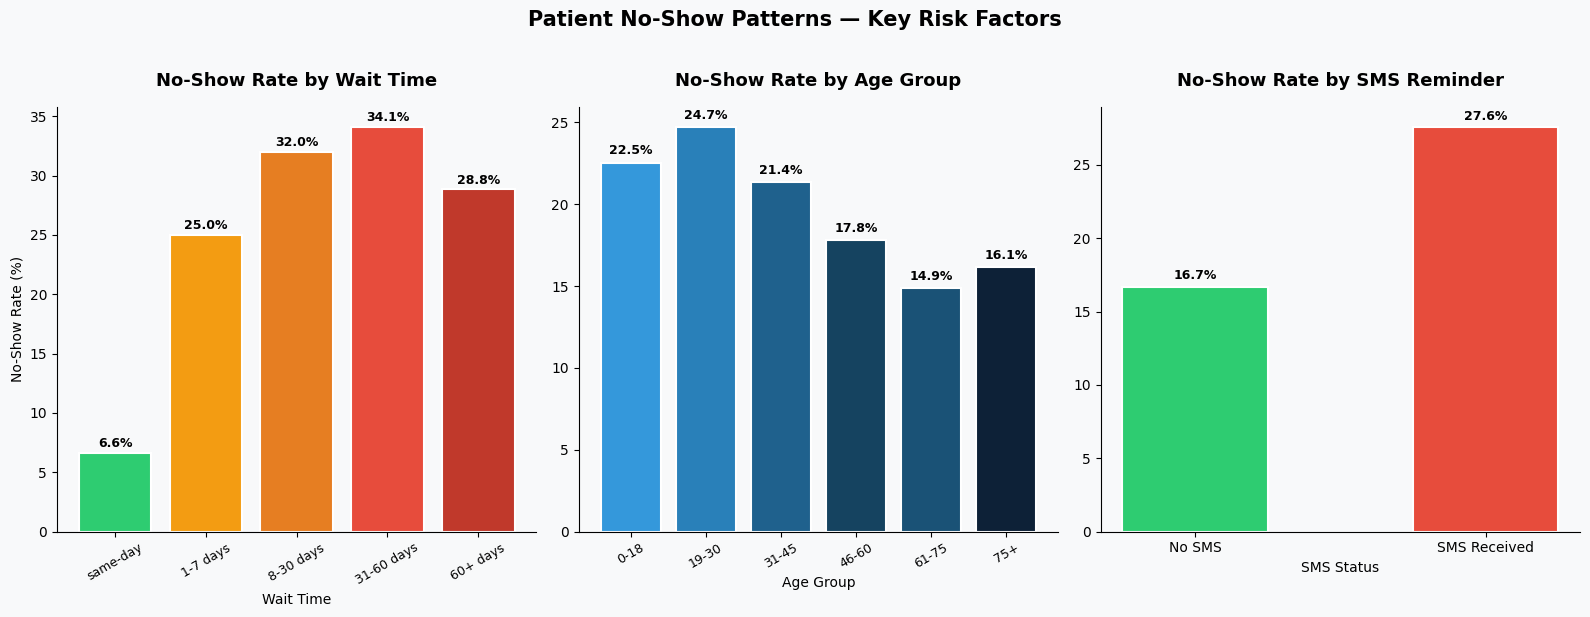

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.patch.set_facecolor('#f8f9fa')

colors_wait = ['#2ecc71','#f39c12','#e67e22','#e74c3c','#c0392b']
colors_age  = ['#3498db','#2980b9','#1f618d','#154360','#1a5276','#0d2137']
colors_sms  = ['#2ecc71','#e74c3c']

# wait time
bars0 = axes[0].bar(wait_noshow.index, wait_noshow.values,
                    color=colors_wait, edgecolor='white', linewidth=1.5)
axes[0].set_title('No-Show Rate by Wait Time', fontsize=13, fontweight='bold', pad=15)
axes[0].set_xlabel('Wait Time', fontsize=10)
axes[0].set_ylabel('No-Show Rate (%)', fontsize=10)
axes[0].set_facecolor('#f8f9fa')
axes[0].tick_params(axis='x', rotation=30, labelsize=9)
axes[0].spines[['top','right']].set_visible(False)
for bar, val in zip(bars0, wait_noshow.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

# age group
bars1 = axes[1].bar(age_noshow.index, age_noshow.values,
                    color=colors_age, edgecolor='white', linewidth=1.5)
axes[1].set_title('No-Show Rate by Age Group', fontsize=13, fontweight='bold', pad=15)
axes[1].set_xlabel('Age Group', fontsize=10)
axes[1].set_facecolor('#f8f9fa')
axes[1].tick_params(axis='x', rotation=30, labelsize=9)
axes[1].spines[['top','right']].set_visible(False)
for bar, val in zip(bars1, age_noshow.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

# sms
bars2 = axes[2].bar(['No SMS','SMS Received'], sms_noshow.values,
                    color=colors_sms, edgecolor='white', linewidth=1.5, width=0.5)
axes[2].set_title('No-Show Rate by SMS Reminder', fontsize=13, fontweight='bold', pad=15)
axes[2].set_xlabel('SMS Status', fontsize=10)
axes[2].set_facecolor('#f8f9fa')
axes[2].spines[['top','right']].set_visible(False)
for bar, val in zip(bars2, sms_noshow.values):
    axes[2].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Patient No-Show Patterns — Key Risk Factors',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('noshow_patterns.png', dpi=150, bbox_inches='tight', facecolor='#f8f9fa')
plt.show()

Exploration is done. Three clear signals — wait time, age, and
SMS status. Now moving into modeling.

Starting with Logistic Regression as a baseline. It's interpretable
and gives a good sense of what's predictable before throwing
something more complex at it.

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report,
                             roc_auc_score, confusion_matrix)
from sklearn.preprocessing import LabelEncoder

# build feature set - keeping it to variables we explored
features = df[['Age', 'wait_days', 'SMS_received',
               'Scholarship', 'Hipertension',
               'Diabetes', 'Alcoholism']].copy()

# encode gender
features['gender_male'] = (df['Gender'] == 'M').astype(int)

# encode day of week
features['is_saturday'] = (df['appt_weekday'] == 'Saturday').astype(int)
features['is_friday'] = (df['appt_weekday'] == 'Friday').astype(int)

target = df['no_show']

X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=42)

print("training size:", X_train.shape)
print("test size:", X_test.shape)
print("\nfeatures used:", features.columns.tolist())

training size: (88420, 10)
test size: (22106, 10)

features used: ['Age', 'wait_days', 'SMS_received', 'Scholarship', 'Hipertension', 'Diabetes', 'Alcoholism', 'gender_male', 'is_saturday', 'is_friday']


Splitting 80/20 for train/test. Using 10 features- mostly things
we already explored plus a couple of demographic variables.

Running Logistic Regression first. Not expecting amazing results
but want a baseline to compare XGBoost against.

In [13]:
from sklearn.preprocessing import StandardScaler

# logistic regression needs scaled features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# train the model
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)

# evaluate
y_pred = lr.predict(X_test_scaled)
y_prob = lr.predict_proba(X_test_scaled)[:, 1]

auc = roc_auc_score(y_test, y_prob)

print("Logistic Regression Results")
print("----------------------------")
print(f"ROC-AUC score: {auc:.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=['showed up', 'no-show']))

Logistic Regression Results
----------------------------
ROC-AUC score: 0.650

Classification Report:
              precision    recall  f1-score   support

   showed up       0.80      0.99      0.89     17715
     no-show       0.34      0.02      0.03      4391

    accuracy                           0.80     22106
   macro avg       0.57      0.50      0.46     22106
weighted avg       0.71      0.80      0.72     22106



Logistic Regression ROC-AUC of 0.65 — not great but not surprising.

The bigger problem is visible in the classification report. The model
is basically ignoring no-shows entirely — only catching 2% of them
(recall of 0.02). It's just predicting "showed up" for almost everyone
because that's the safe bet with an 80/20 class split.

This is the classic imbalanced dataset problem. Accuracy looks fine
at 80% but the model is essentially useless for what we actually
need — flagging who won't show up.

Two things to try next:
1. Tell the model to pay more attention to the minority class
   using class_weight='balanced'
2. Move to XGBoost which handles imbalance better

Going to try both and see what improves.

In [14]:
# retry logistic regression with balanced class weights
lr_balanced = LogisticRegression(random_state=42,
                                  max_iter=1000,
                                  class_weight='balanced')
lr_balanced.fit(X_train_scaled, y_train)

y_pred_bal = lr_balanced.predict(X_test_scaled)
y_prob_bal = lr_balanced.predict_proba(X_test_scaled)[:, 1]

auc_bal = roc_auc_score(y_test, y_prob_bal)

print("Logistic Regression (balanced) Results")
print("----------------------------------------")
print(f"ROC-AUC score: {auc_bal:.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_bal,
      target_names=['showed up', 'no-show']))

Logistic Regression (balanced) Results
----------------------------------------
ROC-AUC score: 0.655

Classification Report:
              precision    recall  f1-score   support

   showed up       0.86      0.69      0.77     17715
     no-show       0.30      0.55      0.39      4391

    accuracy                           0.66     22106
   macro avg       0.58      0.62      0.58     22106
weighted avg       0.75      0.66      0.69     22106



Much better. No-show recall jumped from 2% to 55% — the model is
actually catching more than half of no-shows now. That's the
tradeoff — overall accuracy dropped from 80% to 66% but the model
is now actually useful for the problem we're trying to solve.

AUC barely moved (0.650 to 0.655) which makes sense — balancing
classes changes the threshold, not the underlying signal.

Logistic Regression is probably at its ceiling here. The features
might not have enough linear signal to go much further.
Moving to XGBoost next — it can capture non-linear patterns
that logistic regression misses.

In [15]:
from xgboost import XGBClassifier
# scale_pos_weight handles imbalance in xgboost
# ratio of negative to positive class
scale = y_train.value_counts()[0] / y_train.value_counts()[1]

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=scale,
    random_state=42,
    eval_metric='auc',
    verbosity=0
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

auc_xgb = roc_auc_score(y_test, y_prob_xgb)

print("XGBoost Results")
print("----------------")
print(f"ROC-AUC score: {auc_xgb:.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb,
      target_names=['showed up', 'no-show']))

XGBoost Results
----------------
ROC-AUC score: 0.721

Classification Report:
              precision    recall  f1-score   support

   showed up       0.91      0.56      0.69     17715
     no-show       0.31      0.79      0.44      4391

    accuracy                           0.60     22106
   macro avg       0.61      0.67      0.57     22106
weighted avg       0.79      0.60      0.64     22106



XGBoost ROC-AUC of 0.721 — a meaningful jump from Logistic
Regression's 0.655.

More importantly, no-show recall is now 79%. That means the model
is catching nearly 8 out of 10 no-shows before they happen.
For a clinic trying to reduce scheduling waste, that's actually
operationally useful.

The tradeoff is precision — when the model flags someone as a
no-show, it's only right 31% of the time. In a clinical setting
that might still be acceptable — sending an extra reminder to
someone who was going to show up anyway costs very little.
Missing a no-show costs much more.

Moving to SHAP next to understand WHY the model is making
these predictions. That's the part that makes this useful
to clinicians, not just data scientists.

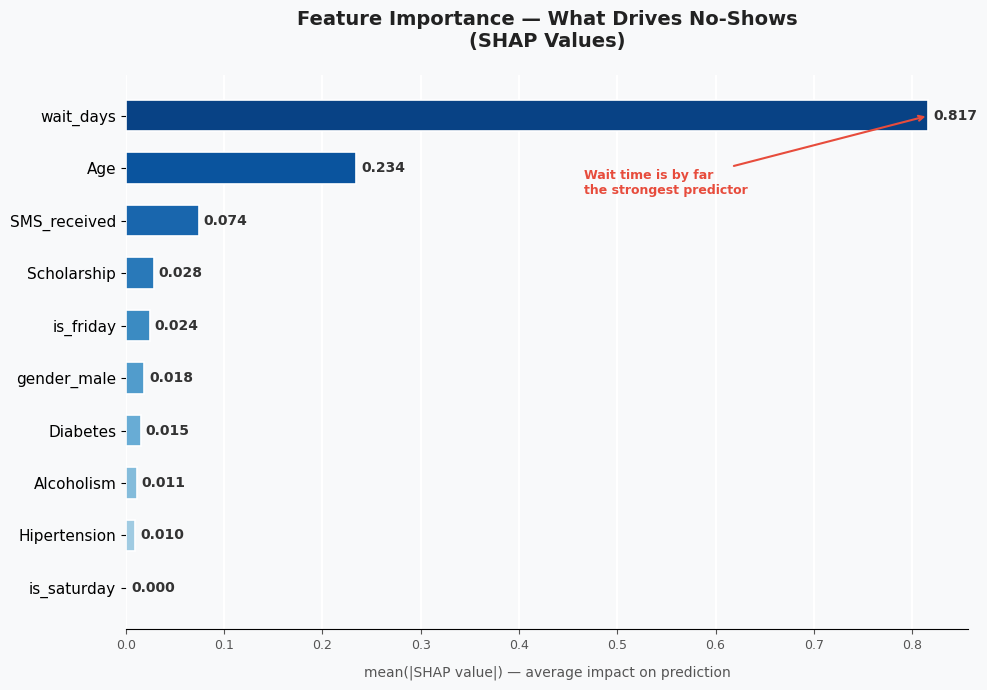

In [17]:
import shap
# shap explainer for xgboost
# styled shap importance chart
fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor('#f8f9fa')
ax.set_facecolor('#f8f9fa')

# feature names and their shap values
feature_names = features.columns.tolist()
shap_means = abs(shap_values).mean(axis=0)

# sort by importance
sorted_idx = shap_means.argsort()
sorted_features = [feature_names[i] for i in sorted_idx]
sorted_values = shap_means[sorted_idx]

# color gradient - most important = darkest blue
colors = plt.cm.Blues(
    [0.3 + 0.7 * (i / len(sorted_values)) for i in range(len(sorted_values))]
)

bars = ax.barh(sorted_features, sorted_values,
               color=colors, edgecolor='white', linewidth=1.2, height=0.6)

# add value labels
for bar, val in zip(bars, sorted_values):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=10, fontweight='bold',
            color='#333333')

ax.set_title('Feature Importance — What Drives No-Shows\n(SHAP Values)',
             fontsize=14, fontweight='bold', pad=20, color='#222222')
ax.set_xlabel('mean(|SHAP value|) — average impact on prediction',
              fontsize=10, labelpad=10, color='#555555')
ax.spines[['top','right','left']].set_visible(False)
ax.tick_params(axis='y', labelsize=11)
ax.tick_params(axis='x', labelsize=9, colors='#555555')
ax.xaxis.grid(True, color='white', linewidth=1.5)
ax.set_axisbelow(True)

# annotation for top feature
ax.annotate('Wait time is by far\nthe strongest predictor',
            xy=(sorted_values[-1], len(sorted_values)-1),
            xytext=(sorted_values[-1]-0.35, len(sorted_values)-2.5),
            fontsize=9, color='#e74c3c', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=1.5))

plt.tight_layout()
plt.savefig('shap_importance.png', dpi=150,
            bbox_inches='tight', facecolor='#f8f9fa')
plt.show()

Final model comparison:


Logistic Regression (baseline):  AUC 0.650, no-show recall 2%


Logistic Regression (balanced):  AUC 0.655, no-show recall 55%


XGBoost (balanced):              AUC 0.721, no-show recall 79%



XGBoost is the clear winner. The SHAP analysis confirms what the
exploratory analysis suggested — wait time is overwhelmingly the
most important predictor (SHAP 0.817), followed by age (0.234)
and SMS status (0.074).

Practical implication: clinics could reduce no-shows by prioritizing
same-day or short-wait scheduling for high-risk patients, and
targeting reminder interventions at younger patients with long
wait times rather than sending SMS reminders broadly.

Limitations: this dataset is from Brazilian clinics in 2016.
Patient behavior may differ across healthcare systems. Model
should be validated on local data before operational use.

In [18]:
from google.colab import files

files.download('noshow_patterns.png')
files.download('shap_importance.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>